In [1]:
# We connect Google Colab to Google Drive, to ensure your notebook (the .ipynb file) is saved and accessible at any time for future use or download
from google.colab import drive
drive.mount('/content/gdrive')
# You can create the folder directly in Colab using the command below; you can change the folder -  ex.: '/content/gdrive/MyDrive/Project_1'
!mkdir -p '/content/gdrive/MyDrive/TF_Project'
print("Folder created successfully")

Mounted at /content/gdrive
Folder created successfully


In [2]:
# Add the path for the Python code for your project folder
import sys
sys.path.append('/content/gdrive/MyDrive/TF_Project')

In [3]:
# Connect the Matplotlib library to visualize images in the model from the your folder
from IPython.display import Image
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans']
matplotlib.rcParams['text.usetex'] = False

In [4]:
import tensorflow as tf
print(tf.test.is_built_with_cuda())
GPU=tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(GPU))
if GPU:
    try:
        for gpu in GPU:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth set for GPU.")
    except RuntimeError as e:
        print(e)
h = tf.constant("Hello")
w = tf.constant(" World!")
hw = h+w
print(hw.numpy().decode("utf-8"))

True
Num GPUs Available:  1
Memory growth set for GPU.
Hello World!


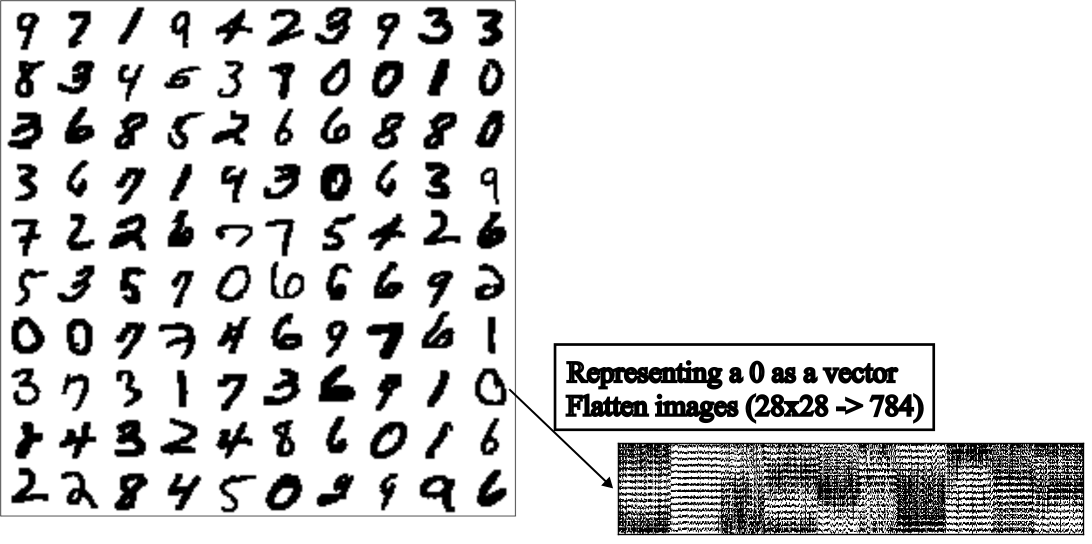

In [5]:
# Configure the path if needed, mainly due to the name of your folder: /content/gdrive/MyDrive/name_folder/MNIST.png
Image('/content/gdrive/MyDrive/TF_Project/MNIST.png', width=700)

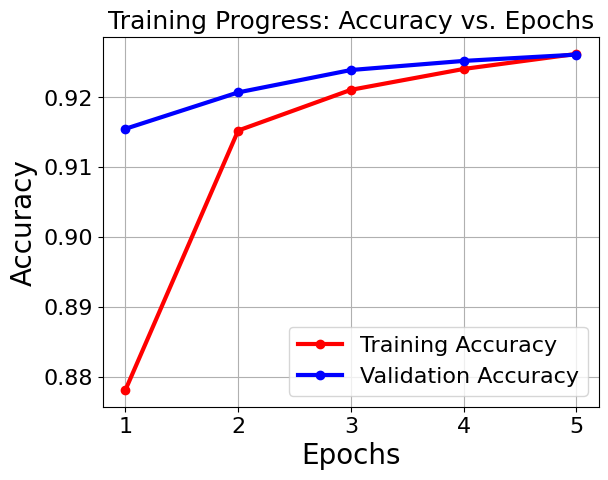

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9260 - loss: 0.2693 - val_accuracy: 0.9261 - val_loss: 0.2677
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9178 - loss: 0.3041
Test accuracy: 0.9261

--- Model Summary (Neurons and Synapses) ---
Layer: dense_11 (Dense), Parameters: 7850, Neurons: 10, Weights: 7840, Bias: 10, Calculated Synapses (Weights + Bias): 7850

Total Neurons (approx, mainly from Dense/RNN): 10
Total Synapses (Total Trainable Parameters): 7850


In [10]:
# Question 1a

%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import AccuracyPlotCallback
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training set size: {x_train.shape}, Test set size: {x_test.shape}")

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Build a simple softmax classifier
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='softmax', input_shape=(784,))
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create the callback instance
plot_callback = AccuracyPlotCallback()

# Debugging: Print if the callback is created correctly
print(f"Callback created: {plot_callback}")

# Train the model with the callback
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test), callbacks=[plot_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the model architecture as a PNG file
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

# Call the function
count_neurons_and_synapses(model)

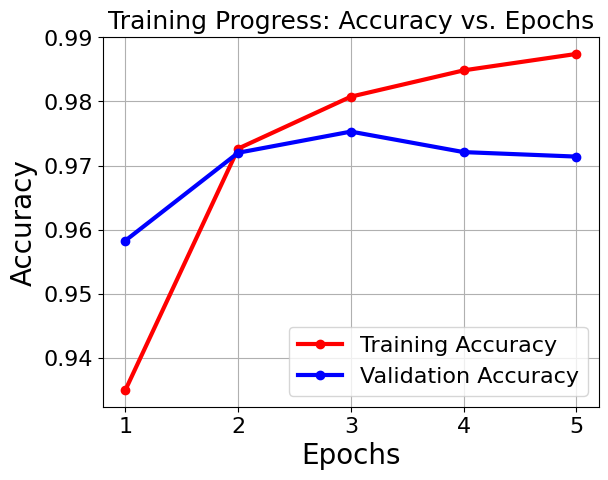

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9874 - loss: 0.0375 - val_accuracy: 0.9714 - val_loss: 0.1177
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9664 - loss: 0.1337
Test accuracy: 0.9714

--- Model Summary (Neurons and Synapses) ---
Layer: dense_1 (Dense), Parameters: 200960, Neurons: 256, Weights: 200704, Bias: 256, Calculated Synapses (Weights + Bias): 200960
Layer: dense_2 (Dense), Parameters: 32896, Neurons: 128, Weights: 32768, Bias: 128, Calculated Synapses (Weights + Bias): 32896
Layer: dense_3 (Dense), Parameters: 8256, Neurons: 64, Weights: 8192, Bias: 64, Calculated Synapses (Weights + Bias): 8256
Layer: dense_4 (Dense), Parameters: 650, Neurons: 10, Weights: 640, Bias: 10, Calculated Synapses (Weights + Bias): 650

Total Neurons (approx, mainly from Dense/RNN): 458
Total Synapses (Total Trainable Parameters): 242762


In [7]:
# Question 1b
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import AccuracyPlotCallback
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training set size: {x_train.shape}, Test set size: {x_test.shape}")

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 3 couches cachées Relu
model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create the callback instance
plot_callback = AccuracyPlotCallback()

# Debugging: Print if the callback is created correctly
print(f"Callback created: {plot_callback}")

# Train the model with the callback
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test), callbacks=[plot_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the model architecture as a PNG file
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

# Call the function
count_neurons_and_synapses(model)

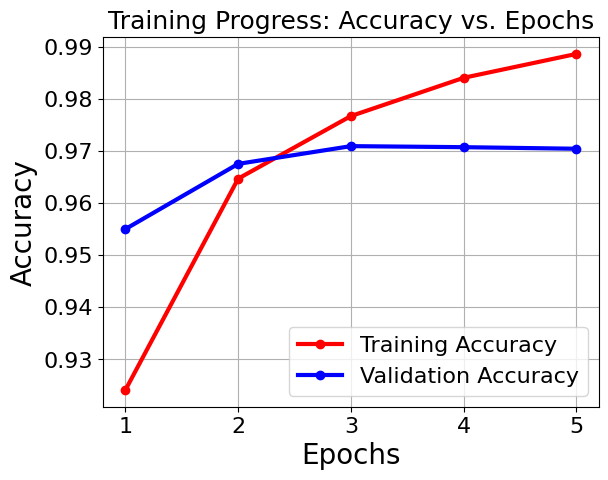

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9877 - loss: 0.0427 - val_accuracy: 0.9704 - val_loss: 0.0960
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9656 - loss: 0.1108
Test accuracy: 0.9704

--- Model Summary (Neurons and Synapses) ---
Layer: dense_5 (Dense), Parameters: 100480, Neurons: 128, Weights: 100352, Bias: 128, Calculated Synapses (Weights + Bias): 100480
Layer: dense_6 (Dense), Parameters: 8256, Neurons: 64, Weights: 8192, Bias: 64, Calculated Synapses (Weights + Bias): 8256
Layer: dense_7 (Dense), Parameters: 650, Neurons: 10, Weights: 640, Bias: 10, Calculated Synapses (Weights + Bias): 650

Total Neurons (approx, mainly from Dense/RNN): 202
Total Synapses (Total Trainable Parameters): 109386


In [8]:
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import AccuracyPlotCallback
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training set size: {x_train.shape}, Test set size: {x_test.shape}")

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 2 couches cachées tanh
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='tanh', input_shape=(784,)),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create the callback instance
plot_callback = AccuracyPlotCallback()

# Debugging: Print if the callback is created correctly
print(f"Callback created: {plot_callback}")

# Train the model with the callback
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test), callbacks=[plot_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the model architecture as a PNG file
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

# Call the function
count_neurons_and_synapses(model)

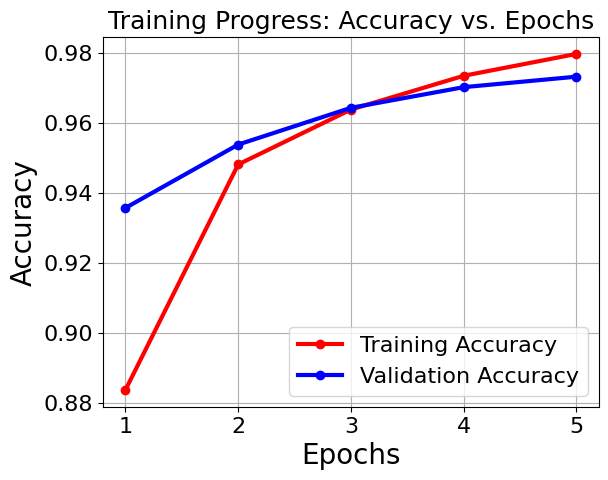

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9796 - loss: 0.0728 - val_accuracy: 0.9733 - val_loss: 0.0860
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9694 - loss: 0.0970
Test accuracy: 0.9733

--- Model Summary (Neurons and Synapses) ---
Layer: dense_8 (Dense), Parameters: 100480, Neurons: 128, Weights: 100352, Bias: 128, Calculated Synapses (Weights + Bias): 100480
Layer: dense_9 (Dense), Parameters: 8256, Neurons: 64, Weights: 8192, Bias: 64, Calculated Synapses (Weights + Bias): 8256
Layer: dense_10 (Dense), Parameters: 650, Neurons: 10, Weights: 640, Bias: 10, Calculated Synapses (Weights + Bias): 650

Total Neurons (approx, mainly from Dense/RNN): 202
Total Synapses (Total Trainable Parameters): 109386


In [9]:
%matplotlib inline
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from callbackPlots import AccuracyPlotCallback
from callbackPlots import count_neurons_and_synapses
import numpy as np
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Training set size: {x_train.shape}, Test set size: {x_test.shape}")

# Flatten images (28x28 -> 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 2 couches cachées sigmoid
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Create the callback instance
plot_callback = AccuracyPlotCallback()

# Debugging: Print if the callback is created correctly
print(f"Callback created: {plot_callback}")

# Train the model with the callback
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test), callbacks=[plot_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Save the model architecture as a PNG file
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True, dpi=300)

# Call the function
count_neurons_and_synapses(model)